<a href="https://colab.research.google.com/github/Jorgellamocca/S2S-PER/blob/main/Agua-precipitable.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ABRIENDO ECMWF IFS ENS

Dataset abierto correctamente.

Dimensiones:
Frozen({'init_time': 265, 'lead_time': 47, 'ensemble_member': 101, 'latitude': 121, 'longitude': 240})

Variable SST:
<xarray.DataArray 'sea_surface_temperature' (init_time: 265, lead_time: 47,
                                             ensemble_member: 101,
                                             latitude: 121, longitude: 240)> Size: 146GB
[36531013200 values with dtype=float32]
Coordinates:
  * init_time                 (init_time) datetime64[ns] 2kB 2026-01-01 ... 2...
  * lead_time                 (lead_time) timedelta64[us] 376B 0 days ... 46 ...
  * ensemble_member           (ensemble_member) int16 202B 0 1 2 3 ... 98 99 100
  * latitude                  (latitude) float64 968B 90.0 88.5 ... -88.5 -90.0
  * longitude                 (longitude) float64 2kB -180.0 -178.5 ... 178.5
    expected_forecast_length  (init_time) timedelta64[us] 2kB ...
    ingested_forecast_length  (init_time) timedelta64[us] 2kB

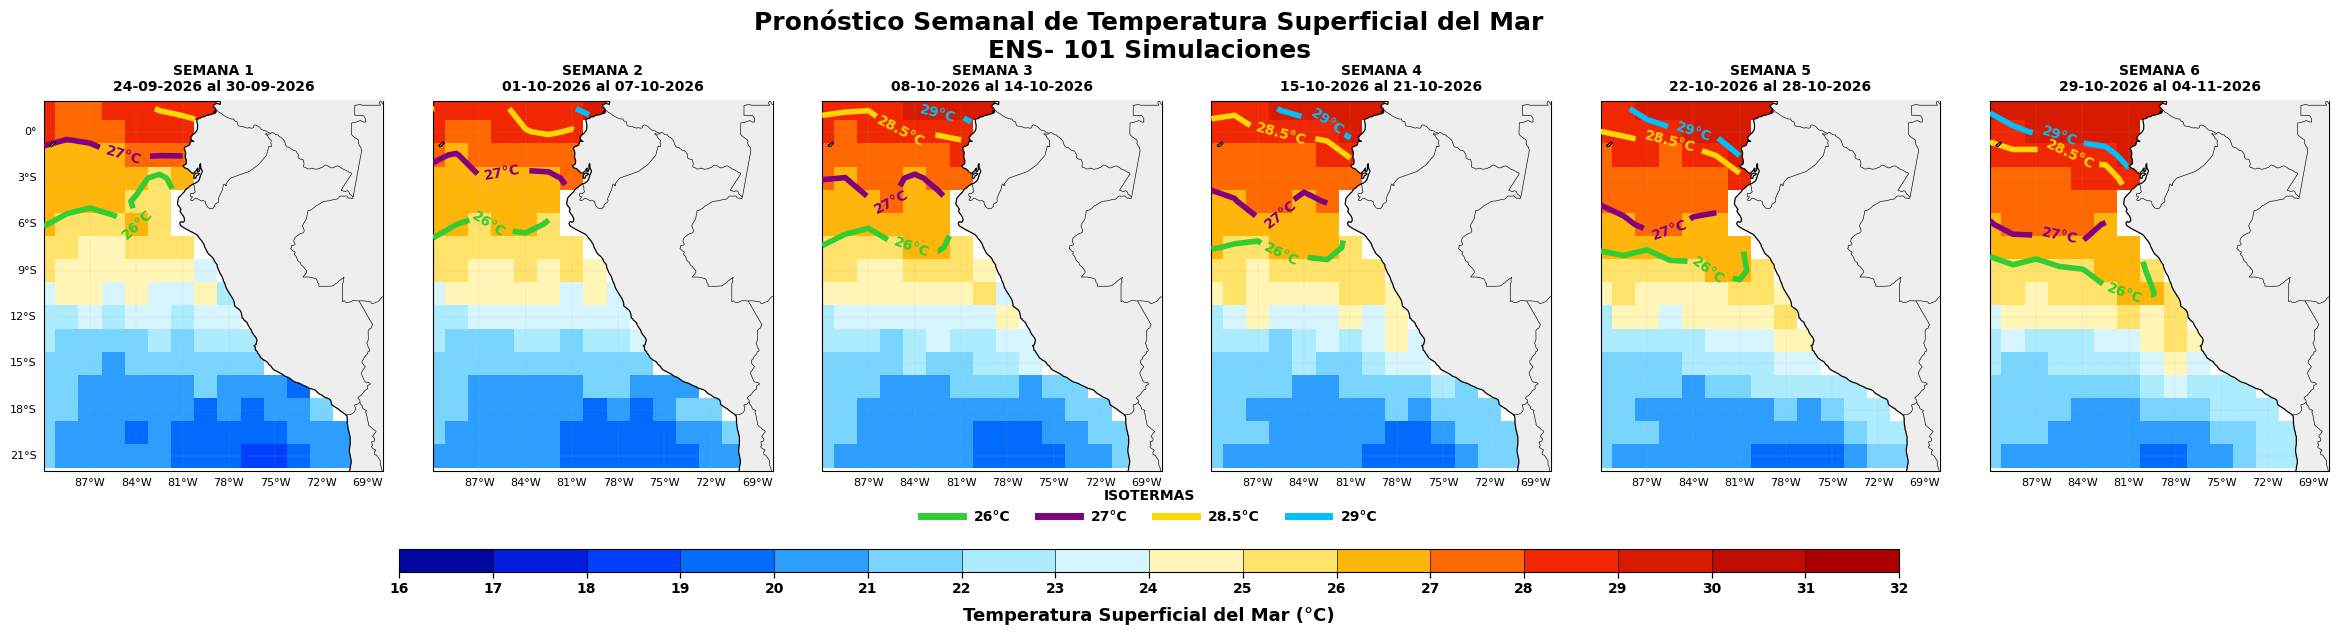

In [16]:
# -*- coding: utf-8 -*-

# ============================================================
# PRONÓSTICO SEMANAL DE TEMPERATURA SUPERFICIAL DEL MAR
# ECMWF IFS ENS - 46 DÍAS
#
# Área:
#   90°W - 68°W
#   22°S - 2°N
#
# Metodología:
#   - Última inicialización disponible
#   - Se descartan las primeras 48 horas
#   - 6 semanas completas de 7 días
#   - Promedio temporal semanal por miembro
#   - Promedio de los 101 miembros
#
# Isotermas:
#   26.0 °C
#   27.0 °C
#   28.5 °C
#   29.0 °C
# ============================================================


# ============================================================
# 0. INSTALAR PAQUETES - GOOGLE COLAB
# ============================================================

!uv pip install -q dynamical-catalog cartopy netcdf4


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import os

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib.lines import Line2D

import dynamical_catalog


# ============================================================
# 2. CONFIGURACIÓN GENERAL
# ============================================================

CATALOGO = (
    "ecmwf-ifs-ens-forecast-46-day-daily-1-5-degree"
)

VAR_SST = "sea_surface_temperature"


# ============================================================
# CONFIGURACIÓN TEMPORAL
# ============================================================

RETRASO_DIAS = 2

N_SEMANAS = 6

DIAS_SEMANA = 7


# ============================================================
# DOMINIO
# ============================================================

LON_MIN = -90
LON_MAX = -68

LAT_MIN = -22
LAT_MAX = 2


# ============================================================
# DIRECTORIO DE SALIDA
# ============================================================

OUTPUT_DIR = "/content/salidas_tsm"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. ABRIR ECMWF IFS ENS
# ============================================================

print("=" * 100)
print("ABRIENDO ECMWF IFS ENS")
print("=" * 100)

ds = dynamical_catalog.open(
    CATALOGO,
    chunks=None
)

print("\nDataset abierto correctamente.")

print("\nDimensiones:")
print(ds.sizes)


# ============================================================
# 4. VERIFICAR VARIABLE SST
# ============================================================

if VAR_SST not in ds.data_vars:

    raise KeyError(
        f"No existe la variable {VAR_SST}"
    )


print("\nVariable SST:")
print(ds[VAR_SST])


# ============================================================
# 5. ÚLTIMA INICIALIZACIÓN DISPONIBLE
# ============================================================

INIT_TIME = ds.init_time.values[-1]

INIT = pd.Timestamp(
    INIT_TIME
)


print("\n" + "=" * 100)
print("INICIALIZACIÓN")
print("=" * 100)

print(
    "Inicialización ECMWF :",
    INIT
)

print(
    "Miembros disponibles :",
    ds.sizes["ensemble_member"]
)

print(
    "Unidad SST           :",
    ds[VAR_SST].attrs.get(
        "units",
        "sin unidad"
    )
)


# ============================================================
# 6. DEFINIR VENTANA OPERATIVA
#
# Se eliminan las primeras 48 horas.
#
# Semana 1 = D+2 ... D+8
# Semana 2 = D+9 ... D+15
# ...
# Semana 6 = D+37 ... D+43
# ============================================================

LEAD_INICIO = pd.Timedelta(
    days=RETRASO_DIAS
)

LEAD_FIN = (
    LEAD_INICIO
    +
    pd.Timedelta(
        days=(
            N_SEMANAS
            *
            DIAS_SEMANA
            - 1
        )
    )
)


FECHA_INICIO = (
    INIT
    +
    LEAD_INICIO
)

FECHA_FIN = (
    INIT
    +
    LEAD_FIN
)


print("\n" + "=" * 100)
print("VENTANA OPERATIVA")
print("=" * 100)

print(
    "Inicialización :",
    INIT
)

print(
    "Inicio (+48 h) :",
    FECHA_INICIO
)

print(
    "Final          :",
    FECHA_FIN
)

print(
    "Lead inicial   :",
    LEAD_INICIO
)

print(
    "Lead final     :",
    LEAD_FIN
)


# ============================================================
# 7. EXTRAER SST
# ============================================================

print("\n" + "=" * 100)
print("EXTRAYENDO TEMPERATURA SUPERFICIAL DEL MAR")
print("=" * 100)


sst = (
    ds[VAR_SST]
    .sel(
        init_time=INIT_TIME
    )
    .sel(
        lead_time=slice(
            LEAD_INICIO,
            LEAD_FIN
        )
    )
)


# ============================================================
# 8. RECORTAR LONGITUD
# ============================================================

sst = sst.sel(
    longitude=slice(
        LON_MIN,
        LON_MAX
    )
)


# ============================================================
# 9. RECORTAR LATITUD
#
# Se controla automáticamente si latitude viene
# ascendente o descendente.
# ============================================================

if (
    float(sst.latitude.values[0])
    >
    float(sst.latitude.values[-1])
):

    sst = sst.sel(
        latitude=slice(
            LAT_MAX,
            LAT_MIN
        )
    )

else:

    sst = sst.sel(
        latitude=slice(
            LAT_MIN,
            LAT_MAX
        )
    )


# ============================================================
# 10. CARGAR DATOS
# ============================================================

print("\nCargando datos...")

sst = sst.load()

print("Datos cargados correctamente.")


print("\nDimensiones finales:")
print(sst.dims)

print("\nShape:")
print(sst.shape)


print("\nDominio real seleccionado:")

print(
    "Longitud:",
    float(sst.longitude.min()),
    "a",
    float(sst.longitude.max())
)

print(
    "Latitud :",
    float(sst.latitude.min()),
    "a",
    float(sst.latitude.max())
)


print("\nRango SST:")

print(
    float(
        sst.min(
            skipna=True
        )
    ),
    "a",
    float(
        sst.max(
            skipna=True
        )
    ),
    "°C"
)


# ============================================================
# 11. CONTROL TEMPORAL
# ============================================================

N_DIAS_ESPERADOS = (
    N_SEMANAS
    *
    DIAS_SEMANA
)

N_DIAS_DISPONIBLES = (
    sst.sizes[
        "lead_time"
    ]
)


print("\n" + "=" * 100)
print("CONTROL TEMPORAL")
print("=" * 100)

print(
    "Días esperados   :",
    N_DIAS_ESPERADOS
)

print(
    "Días disponibles :",
    N_DIAS_DISPONIBLES
)


if (
    N_DIAS_DISPONIBLES
    <
    N_DIAS_ESPERADOS
):

    raise ValueError(
        f"No existen suficientes días. "
        f"Disponibles={N_DIAS_DISPONIBLES}, "
        f"necesarios={N_DIAS_ESPERADOS}"
    )


print(
    "\nOK: existen las 6 semanas completas."
)


# ============================================================
# 12. CALCULAR PROMEDIOS SEMANALES
#
# Paso 1:
#   promedio de 7 días para cada miembro
#
# Paso 2:
#   promedio de los miembros
# ============================================================

sst_semanal = {}

sst_semanal_miembros = {}

fechas_semanas = {}


print("\n" + "=" * 100)
print("PROMEDIOS SEMANALES")
print("=" * 100)


for semana in range(
    1,
    N_SEMANAS + 1
):


    # ========================================================
    # ÍNDICES TEMPORALES
    # ========================================================

    i0 = (
        (semana - 1)
        *
        DIAS_SEMANA
    )

    i1 = (
        i0
        +
        DIAS_SEMANA
    )


    # ========================================================
    # EXTRAER LOS 7 DÍAS
    # ========================================================

    datos_semana = (
        sst.isel(
            lead_time=slice(
                i0,
                i1
            )
        )
    )


    # ========================================================
    # VERIFICAR 7 DÍAS
    # ========================================================

    if (
        datos_semana.sizes[
            "lead_time"
        ]
        != DIAS_SEMANA
    ):

        raise ValueError(
            f"Semana {semana}: "
            f"solo tiene "
            f"{datos_semana.sizes['lead_time']} días."
        )


    # ========================================================
    # PROMEDIO DE LOS 7 DÍAS PARA CADA MIEMBRO
    # ========================================================

    promedio_miembros = (
        datos_semana.mean(
            dim="lead_time",
            skipna=True
        )
    )


    sst_semanal_miembros[
        semana
    ] = promedio_miembros


    # ========================================================
    # PROMEDIO DE LOS 101 MIEMBROS
    # ========================================================

    promedio_ensamble = (
        promedio_miembros.mean(
            dim="ensemble_member",
            skipna=True
        )
    )


    # ========================================================
    # RENOMBRAR LAT/LON
    # ========================================================

    promedio_ensamble = (
        promedio_ensamble.rename(
            {
                "latitude": "lat",
                "longitude": "lon"
            }
        )
    )


    promedio_ensamble = (
        promedio_ensamble.sortby(
            "lat"
        )
    )


    promedio_ensamble = (
        promedio_ensamble.sortby(
            "lon"
        )
    )


    sst_semanal[
        semana
    ] = promedio_ensamble


    # ========================================================
    # FECHAS
    # ========================================================

    if (
        "valid_time"
        in datos_semana.coords
    ):

        fechas = pd.to_datetime(
            datos_semana[
                "valid_time"
            ].values
        )

        fecha_ini = pd.Timestamp(
            fechas[0]
        )

        fecha_fin = pd.Timestamp(
            fechas[-1]
        )


    else:

        lead_ini = pd.Timedelta(
            datos_semana[
                "lead_time"
            ].values[0]
        )

        lead_fin = pd.Timedelta(
            datos_semana[
                "lead_time"
            ].values[-1]
        )

        fecha_ini = (
            INIT
            +
            lead_ini
        )

        fecha_fin = (
            INIT
            +
            lead_fin
        )


    fechas_semanas[
        semana
    ] = (
        fecha_ini,
        fecha_fin
    )


    # ========================================================
    # ESTADÍSTICAS
    # ========================================================

    minimo = float(
        promedio_ensamble.min(
            skipna=True
        )
    )

    maximo = float(
        promedio_ensamble.max(
            skipna=True
        )
    )

    media = float(
        promedio_ensamble.mean(
            skipna=True
        )
    )


    print(
        f"Semana {semana} | "
        f"{fecha_ini:%d-%m-%Y} al "
        f"{fecha_fin:%d-%m-%Y} | "
        f"MIN={minimo:.2f} °C | "
        f"MAX={maximo:.2f} °C | "
        f"MEDIA={media:.2f} °C"
    )


# ============================================================
# 13. PALETA SST
# ============================================================

sst_colors = [

    "#00079F",
    "#0116C8",
    "#0125F0",
    "#013DFF",

    "#015AFE",
    "#0177FE",
    "#2699FE",
    "#58BCFE",

    "#8AE0FE",
    "#A8EAFE",
    "#C3F0FF",
    "#DEF7FF",

    "#FFF6C1",
    "#FFF19D",
    "#FFDE5D",
    "#FFC50E",

    "#FF9501",
    "#FF6101",
    "#F62A00",
    "#E72200",

    "#D71A00",
    "#C81101",
    "#B80901",
    "#A90100",
]


# ============================================================
# 14. ESCALA SST DISCRETA
# 16, 17, 18 ... 32 °C
# ============================================================

SST_MIN = 16

SST_MAX = 32

SST_INTERVALO = 1


SST_LEVELS = np.arange(
    SST_MIN,
    SST_MAX
    +
    SST_INTERVALO,
    SST_INTERVALO
)


# ============================================================
# 15. CREAR PALETA DISCRETA
# ============================================================

sst_cmap_base = (
    mcolors.LinearSegmentedColormap.from_list(
        "sst_base",
        sst_colors,
        N=256
    )
)


sst_cmap = (
    mcolors.ListedColormap(
        sst_cmap_base(
            np.linspace(
                0,
                1,
                len(SST_LEVELS) - 1
            )
        ),
        name="sst_discreta"
    )
)


# ============================================================
# NORMALIZACIÓN
# ============================================================

sst_norm = (
    mcolors.BoundaryNorm(
        boundaries=SST_LEVELS,
        ncolors=sst_cmap.N,
        clip=True
    )
)


# ============================================================
# 16. ISOTERMAS
#
# 26 °C
# 27 °C
# 28.5 °C
# 29 °C
# ============================================================

contour_levels = [

    26.0,

    27.0,

    28.5,

    29.0
]


contour_colors = [

    "limegreen",      # 26 °C

    "purple",         # 27 °C

    "gold",           # 28.5 °C

    "deepskyblue"     # 29 °C
]


GROSOR_ISOTERMAS = 4.0

TAMANO_ETIQUETA_ISOTERMA = 10


# ============================================================
# 17. FUNCIÓN GEOGRAFÍA
# SIN TOPOGRAFÍA
# ============================================================

def agregar_geografia(
    ax
):

    # --------------------------------------------------------
    # TIERRA
    # --------------------------------------------------------

    ax.add_feature(
        cfeature.LAND,
        facecolor="#EEEEEE",
        edgecolor="none",
        zorder=8
    )


    # --------------------------------------------------------
    # COSTA
    # --------------------------------------------------------

    ax.add_feature(
        cfeature.COASTLINE,
        linewidth=0.9,
        edgecolor="black",
        zorder=12
    )


    # --------------------------------------------------------
    # FRONTERAS
    # --------------------------------------------------------

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.45,
        edgecolor="black",
        zorder=12
    )


# ============================================================
# 18. FUNCIÓN PARA ISOTERMAS
# ============================================================

def agregar_isotermas(
    ax,
    campo
):

    try:

        cs = ax.contour(

            campo.lon,

            campo.lat,

            campo,

            levels=
            contour_levels,

            colors=
            contour_colors,

            linewidths=
            GROSOR_ISOTERMAS,

            transform=
            ccrs.PlateCarree(),

            zorder=7
        )


        # ====================================================
        # ETIQUETAS
        # ====================================================

        textos = ax.clabel(

            cs,

            fmt={
                26.0: "26°C",
                27.0: "27°C",
                28.5: "28.5°C",
                29.0: "29°C"
            },

            inline=True,

            fontsize=
            TAMANO_ETIQUETA_ISOTERMA
        )


        # ====================================================
        # NEGRITA
        # ====================================================

        for texto in textos:

            texto.set_fontweight(
                "bold"
            )

            texto.set_bbox(
                None
            )


    except Exception as e:

        print(
            "Advertencia al dibujar isotermas:",
            e
        )


# ============================================================
# 19. CONFIGURAR MAPA
# ============================================================

def configurar_mapa(
    ax,
    mostrar_latitud=False
):

    # --------------------------------------------------------
    # DOMINIO
    # --------------------------------------------------------

    ax.set_extent(
        [
            LON_MIN,
            LON_MAX,
            LAT_MIN,
            LAT_MAX
        ],
        crs=ccrs.PlateCarree()
    )


    # --------------------------------------------------------
    # GRILLA
    # --------------------------------------------------------

    gl = ax.gridlines(

        draw_labels=True,

        crs=ccrs.PlateCarree(),

        linestyle="--",

        linewidth=0.30,

        alpha=0.45
    )


    gl.top_labels = False

    gl.right_labels = False


    gl.left_labels = (
        mostrar_latitud
    )


    gl.xlabel_style = {
        "size": 8
    }


    gl.ylabel_style = {
        "size": 8
    }


# ============================================================
# 20. CREAR FIGURA
#
# 1 FILA x 6 SEMANAS
# ============================================================

fig, axs = plt.subplots(

    1,

    6,

    figsize=(
        25,
        6.5
    ),

    subplot_kw={
        "projection":
        ccrs.PlateCarree()
    }
)


# ============================================================
# TÍTULO GENERAL
# ============================================================

fig.suptitle(

    "Pronóstico Semanal de Temperatura Superficial del Mar\n"
    "ENS- 101 Simulaciones",

    fontsize=18,

    fontweight="bold",

    y=0.96
)


im = None


# ============================================================
# 21. GRAFICAR LAS 6 SEMANAS
# ============================================================

for i in range(
    N_SEMANAS
):


    semana = (
        i + 1
    )


    ax = axs[i]


    # ========================================================
    # CONFIGURACIÓN DEL MAPA
    # ========================================================

    configurar_mapa(

        ax,

        mostrar_latitud=(
            i == 0
        )
    )


    campo = (
        sst_semanal[
            semana
        ]
    )


    # ========================================================
    # SST
    # ========================================================

    im = ax.pcolormesh(

        campo.lon,

        campo.lat,

        campo,

        cmap=
        sst_cmap,

        norm=
        sst_norm,

        shading="auto",

        transform=
        ccrs.PlateCarree(),

        zorder=1
    )


    # ========================================================
    # ISOTERMAS
    # ========================================================

    agregar_isotermas(
        ax,
        campo
    )


    # ========================================================
    # GEOGRAFÍA
    # ========================================================

    agregar_geografia(
        ax
    )


    # ========================================================
    # FECHAS
    # ========================================================

    fecha_ini, fecha_fin = (
        fechas_semanas[
            semana
        ]
    )


    # ========================================================
    # TÍTULO DEL PANEL
    # ========================================================

    ax.set_title(

        f"SEMANA {semana}\n"
        f"{fecha_ini:%d-%m-%Y} al "
        f"{fecha_fin:%d-%m-%Y}",

        fontsize=10,

        fontweight="bold",

        pad=7
    )


# ============================================================
# 22. ESPACIADO
# ============================================================

plt.subplots_adjust(

    left=0.055,

    right=0.975,

    bottom=0.25,

    top=0.82,

    wspace=0.10
)


# ============================================================
# 23. COLORBAR SST
# ============================================================

if im is not None:


    cbar_ax = fig.add_axes(
        [
            0.20,
            0.095,
            0.60,
            0.035
        ]
    )


    cbar = fig.colorbar(

        im,

        cax=cbar_ax,

        orientation="horizontal",

        boundaries=SST_LEVELS,

        ticks=SST_LEVELS,

        spacing="uniform",

        drawedges=True
    )


    cbar.set_label(

        "Temperatura Superficial del Mar (°C)",

        fontsize=13,

        fontweight="bold",

        labelpad=8
    )


    cbar.ax.tick_params(

        axis="x",

        labelsize=10,

        length=4,

        width=0.9,

        pad=3
    )


    cbar.ax.set_xticklabels(
        [
            f"{int(v)}"
            for v in SST_LEVELS
        ]
    )


    for tick in (
        cbar.ax.get_xticklabels()
    ):

        tick.set_fontweight(
            "bold"
        )


    cbar.dividers.set_linewidth(
        0.45
    )


# ============================================================
# 24. LEYENDA DE ISOTERMAS
# ============================================================

legend_elements = [


    # --------------------------------------------------------
    # 26 °C
    # --------------------------------------------------------

    Line2D(
        [0],
        [0],

        color="limegreen",

        lw=5,

        label="26°C"
    ),


    # --------------------------------------------------------
    # 27 °C
    # --------------------------------------------------------

    Line2D(
        [0],
        [0],

        color="purple",

        lw=5,

        label="27°C"
    ),


    # --------------------------------------------------------
    # 28.5 °C
    # --------------------------------------------------------

    Line2D(
        [0],
        [0],

        color="gold",

        lw=5,

        label="28.5°C"
    ),


    # --------------------------------------------------------
    # 29 °C
    # --------------------------------------------------------

    Line2D(
        [0],
        [0],

        color="deepskyblue",

        lw=5,

        label="29°C"
    )

]


leyenda = fig.legend(

    handles=
    legend_elements,

    loc=
    "lower center",

    bbox_to_anchor=(
        0.5,
        0.15
    ),

    ncol=4,

    fontsize=10,

    frameon=False,

    title=
    "ISOTERMAS",

    handlelength=3
)


plt.setp(

    leyenda.get_texts(),

    fontweight="bold"
)


leyenda.get_title().set_fontweight(
    "bold"
)


# ============================================================
# 25. INFORMACIÓN INFERIOR
# ============================================================



# ============================================================
# 26. GUARDAR FIGURA
# ============================================================

fecha_init_str = (
    INIT.strftime(
        "%Y%m%d"
    )
)


OUTPUT_FILE = os.path.join(

    OUTPUT_DIR,

    (
        f"ocen_ecmwf_ifs_"
        f"{fecha_init_str}_"
        f"sst_semanal.png"
    )
)


plt.savefig(

    OUTPUT_FILE,

    dpi=300,

    bbox_inches="tight",

    facecolor="white"
)


# ============================================================
# 27. INFORMACIÓN FINAL
# ============================================================

print("\n" + "=" * 100)

print(
    "FIGURA GUARDADA:"
)

print(
    OUTPUT_FILE
)

print("=" * 100)


print("\nSEMANAS GENERADAS:")

for semana in range(
    1,
    N_SEMANAS + 1
):

    fecha_ini, fecha_fin = (
        fechas_semanas[
            semana
        ]
    )

    print(
        f"Semana {semana}: "
        f"{fecha_ini:%d-%m-%Y} "
        f"al "
        f"{fecha_fin:%d-%m-%Y}"
    )


# ============================================================
# 28. MOSTRAR FIGURA
# ============================================================

plt.show()

ABRIENDO ECMWF IFS ENS

Dataset abierto correctamente.

Dimensiones:
Frozen({'init_time': 265, 'lead_time': 47, 'ensemble_member': 101, 'latitude': 121, 'longitude': 240})

VARIABLE DE AGUA PRECIPITABLE
<xarray.DataArray 'total_column_water_atmosphere' (init_time: 265,
                                                   lead_time: 47,
                                                   ensemble_member: 101,
                                                   latitude: 121, longitude: 240)> Size: 146GB
[36531013200 values with dtype=float32]
Coordinates:
  * init_time                 (init_time) datetime64[ns] 2kB 2026-01-01 ... 2...
  * lead_time                 (lead_time) timedelta64[us] 376B 0 days ... 46 ...
  * ensemble_member           (ensemble_member) int16 202B 0 1 2 3 ... 98 99 100
  * latitude                  (latitude) float64 968B 90.0 88.5 ... -88.5 -90.0
  * longitude                 (longitude) float64 2kB -180.0 -178.5 ... 178.5
    expected_forecast_length  (init_time) 

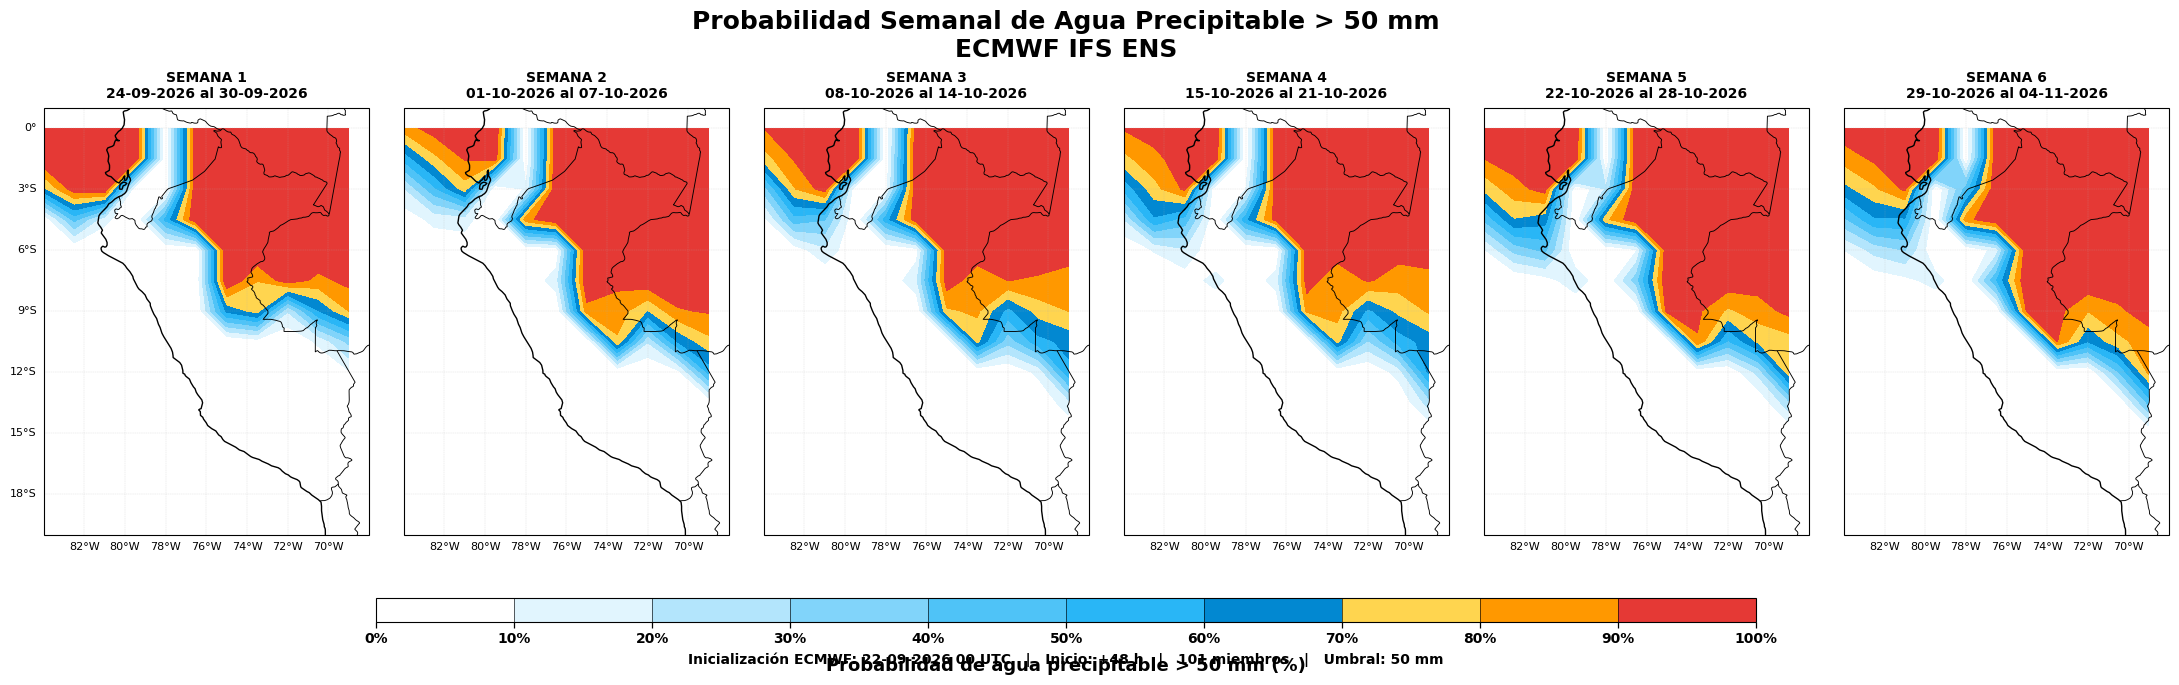

In [18]:
# -*- coding: utf-8 -*-

# ============================================================
# PROBABILIDAD SEMANAL DE AGUA PRECIPITABLE > 50 mm
# ECMWF IFS ENS - 46 DÍAS
#
# Variable:
#   total_column_water_atmosphere
#
# Producto:
#   Probabilidad (%) de que el promedio semanal
#   de agua precipitable supere 50 mm
#
# Dominio:
#   Perú y alrededores
#   84°W - 68°W
#   20°S - 1°N
#
# Metodología:
#   1. Última inicialización disponible
#   2. Inicio en D+2 (+48 h)
#   3. 6 semanas x 7 días = 42 días
#   4. Promedio de 7 días PARA CADA MIEMBRO
#   5. Determinar miembros con PW semanal > 50 mm
#   6. Probabilidad = miembros que superan 50 / total * 100
#
# NO SE APLICA MÁSCARA DE PERÚ
# ============================================================


# ============================================================
# 0. INSTALAR PAQUETES EN GOOGLE COLAB
# ============================================================

!uv pip install -q dynamical-catalog cartopy netcdf4


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import os

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import dynamical_catalog


# ============================================================
# 2. CONFIGURACIÓN GENERAL
# ============================================================

CATALOGO = (
    "ecmwf-ifs-ens-forecast-46-day-daily-1-5-degree"
)

VAR_PW = "total_column_water_atmosphere"


# ============================================================
# CONFIGURACIÓN TEMPORAL
# ============================================================

RETRASO_DIAS = 2

N_SEMANAS = 6

DIAS_SEMANA = 7


# ============================================================
# UMBRAL
# ============================================================

UMBRAL_PW = 50.0


# ============================================================
# DOMINIO PERÚ
#
# NO es una máscara.
# Solo es una ventana rectangular.
# ============================================================

LON_MIN = -84
LON_MAX = -68

LAT_MIN = -20
LAT_MAX = 1


# ============================================================
# DIRECTORIO DE SALIDA
# ============================================================

OUTPUT_DIR = (
    "/content/salidas_probabilidad_agua_precipitable"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. ABRIR ECMWF IFS ENS
# ============================================================

print("=" * 100)
print("ABRIENDO ECMWF IFS ENS")
print("=" * 100)


ds = dynamical_catalog.open(
    CATALOGO,
    chunks=None
)


print("\nDataset abierto correctamente.")

print("\nDimensiones:")
print(ds.sizes)


# ============================================================
# 4. VERIFICAR VARIABLE
# ============================================================

if VAR_PW not in ds.data_vars:

    raise KeyError(
        f"No existe la variable '{VAR_PW}' "
        f"en el catálogo."
    )


print("\n" + "=" * 100)
print("VARIABLE DE AGUA PRECIPITABLE")
print("=" * 100)

print(
    ds[VAR_PW]
)


print("\nAtributos:")

print(
    ds[VAR_PW].attrs
)


# ============================================================
# 5. VERIFICAR UNIDADES
# ============================================================

UNIDADES = (
    ds[VAR_PW]
    .attrs
    .get(
        "units",
        ""
    )
)


print("\n" + "=" * 100)
print("UNIDADES")
print("=" * 100)

print(
    "Unidades originales:",
    UNIDADES
)


# ============================================================
# 6. ÚLTIMA INICIALIZACIÓN DISPONIBLE
# ============================================================

INIT_TIME = (
    ds.init_time.values[-1]
)

INIT = pd.Timestamp(
    INIT_TIME
)


N_MIEMBROS = (
    ds.sizes[
        "ensemble_member"
    ]
)


print("\n" + "=" * 100)
print("INICIALIZACIÓN")
print("=" * 100)

print(
    "Inicialización:",
    INIT
)

print(
    "Número de miembros:",
    N_MIEMBROS
)


# ============================================================
# 7. VENTANA TEMPORAL
#
# Semana 1 = D+2  ... D+8
# Semana 2 = D+9  ... D+15
# Semana 3 = D+16 ... D+22
# Semana 4 = D+23 ... D+29
# Semana 5 = D+30 ... D+36
# Semana 6 = D+37 ... D+43
# ============================================================

LEAD_INICIO = pd.Timedelta(
    days=RETRASO_DIAS
)


LEAD_FIN = (
    LEAD_INICIO
    +
    pd.Timedelta(
        days=(
            N_SEMANAS
            *
            DIAS_SEMANA
            - 1
        )
    )
)


FECHA_INICIO = (
    INIT
    +
    LEAD_INICIO
)


FECHA_FIN = (
    INIT
    +
    LEAD_FIN
)


print("\n" + "=" * 100)
print("VENTANA OPERATIVA")
print("=" * 100)

print(
    "Inicialización :",
    INIT
)

print(
    "Inicio (+48 h) :",
    FECHA_INICIO
)

print(
    "Final          :",
    FECHA_FIN
)

print(
    "Lead inicial   :",
    LEAD_INICIO
)

print(
    "Lead final     :",
    LEAD_FIN
)


# ============================================================
# 8. EXTRAER VARIABLE
# ============================================================

print("\n" + "=" * 100)
print("EXTRAYENDO AGUA PRECIPITABLE")
print("=" * 100)


pw = (
    ds[VAR_PW]
    .sel(
        init_time=INIT_TIME
    )
    .sel(
        lead_time=slice(
            LEAD_INICIO,
            LEAD_FIN
        )
    )
)


# ============================================================
# 9. NORMALIZAR LONGITUD
#
# Si viene 0 ... 360,
# transformar a -180 ... 180.
# ============================================================

if (
    float(
        pw.longitude.max()
    )
    >
    180
):

    pw = pw.assign_coords(

        longitude=(
            (
                pw.longitude
                +
                180
            )
            %
            360
        )
        -
        180

    )


    pw = pw.sortby(
        "longitude"
    )


# ============================================================
# 10. RECORTAR LONGITUD
# ============================================================

pw = pw.sel(

    longitude=slice(
        LON_MIN,
        LON_MAX
    )

)


# ============================================================
# 11. RECORTAR LATITUD
#
# Funciona con latitud ascendente o descendente.
# ============================================================

if (
    float(
        pw.latitude.values[0]
    )
    >
    float(
        pw.latitude.values[-1]
    )
):

    pw = pw.sel(

        latitude=slice(
            LAT_MAX,
            LAT_MIN
        )

    )

else:

    pw = pw.sel(

        latitude=slice(
            LAT_MIN,
            LAT_MAX
        )

    )


# ============================================================
# 12. CARGAR SOLO EL DOMINIO
# ============================================================

print("\nCargando datos...")

pw = pw.load()

print("Datos cargados correctamente.")


# ============================================================
# 13. INFORMACIÓN DEL CAMPO
# ============================================================

print("\n" + "=" * 100)
print("DATOS EXTRAÍDOS")
print("=" * 100)


print(
    "Dimensiones:",
    pw.dims
)


print(
    "Shape:",
    pw.shape
)


print(
    "Longitud:",
    float(
        pw.longitude.min()
    ),
    "a",
    float(
        pw.longitude.max()
    )
)


print(
    "Latitud:",
    float(
        pw.latitude.min()
    ),
    "a",
    float(
        pw.latitude.max()
    )
)


print(
    "Valor mínimo:",
    float(
        pw.min(
            skipna=True
        )
    )
)


print(
    "Valor máximo:",
    float(
        pw.max(
            skipna=True
        )
    )
)


# ============================================================
# 14. AGUA PRECIPITABLE EN mm
#
# Para agua:
#
#   1 kg m-2 = 1 mm
#
# Por lo tanto, si la variable está expresada en kg m-2,
# el valor numérico es equivalente a mm.
# ============================================================

pw_mm = pw.copy()

pw_mm.attrs["units"] = "mm"


# ============================================================
# 15. CONTROL DE LOS 42 DÍAS
# ============================================================

N_DIAS_ESPERADOS = (
    N_SEMANAS
    *
    DIAS_SEMANA
)


N_DIAS_DISPONIBLES = (
    pw_mm.sizes[
        "lead_time"
    ]
)


print("\n" + "=" * 100)
print("CONTROL TEMPORAL")
print("=" * 100)


print(
    "Días esperados:",
    N_DIAS_ESPERADOS
)


print(
    "Días disponibles:",
    N_DIAS_DISPONIBLES
)


if (
    N_DIAS_DISPONIBLES
    <
    N_DIAS_ESPERADOS
):

    raise ValueError(

        f"No existen suficientes días. "
        f"Disponibles = {N_DIAS_DISPONIBLES}; "
        f"necesarios = {N_DIAS_ESPERADOS}."

    )


print(
    "\nOK: existen 6 semanas completas."
)


# ============================================================
# 16. PROBABILIDAD SEMANAL
#
# IMPORTANTE:
#
# Primero calculamos:
#
#       promedio semanal PARA CADA MIEMBRO
#
# Luego:
#
#       PW_semanal > 50 mm
#
# Finalmente:
#
#       número miembros > 50
# P = ------------------------- x 100
#       número total miembros
#
# ============================================================

prob_semanal = {}

pw_promedio_semanal = {}

fechas_semanas = {}


print("\n" + "=" * 100)
print("PROBABILIDAD SEMANAL DE PW > 50 mm")
print("=" * 100)


for semana in range(
    1,
    N_SEMANAS + 1
):


    # ========================================================
    # POSICIONES TEMPORALES
    # ========================================================

    i0 = (
        (semana - 1)
        *
        DIAS_SEMANA
    )


    i1 = (
        i0
        +
        DIAS_SEMANA
    )


    # ========================================================
    # EXTRAER LOS 7 DÍAS
    # ========================================================

    datos_semana = (
        pw_mm.isel(

            lead_time=slice(
                i0,
                i1
            )

        )
    )


    # ========================================================
    # VERIFICACIÓN
    # ========================================================

    n_dias_semana = (
        datos_semana.sizes[
            "lead_time"
        ]
    )


    if (
        n_dias_semana
        !=
        DIAS_SEMANA
    ):

        raise ValueError(

            f"Semana {semana}: "
            f"se encontraron "
            f"{n_dias_semana} días."

        )


    # ========================================================
    # PASO 1
    #
    # PROMEDIO DE 7 DÍAS
    # PARA CADA MIEMBRO
    #
    # Resultado:
    #
    # ensemble_member x latitude x longitude
    # ========================================================

    pw_semana_miembro = (
        datos_semana.mean(

            dim="lead_time",

            skipna=True

        )
    )


    # ========================================================
    # GUARDAR PROMEDIO SEMANAL
    # ========================================================

    pw_promedio_semanal[
        semana
    ] = (
        pw_semana_miembro
    )


    # ========================================================
    # PASO 2
    #
    # ¿QUÉ MIEMBROS SUPERAN 50 mm?
    #
    # True  = PW > 50
    # False = PW <= 50
    # ========================================================

    supera_umbral = (

        pw_semana_miembro
        >
        UMBRAL_PW

    )


    # ========================================================
    # PASO 3
    #
    # PROBABILIDAD (%)
    #
    # True = 1
    # False = 0
    #
    # promedio de miembros * 100
    # ========================================================

    prob = (

        supera_umbral.mean(

            dim=
            "ensemble_member"

        )

        *

        100.0

    )


    # ========================================================
    # RENOMBRAR COORDENADAS
    # ========================================================

    prob = prob.rename(

        {
            "latitude":
            "lat",

            "longitude":
            "lon"
        }

    )


    # ========================================================
    # ORDENAR
    # ========================================================

    prob = (
        prob
        .sortby("lat")
        .sortby("lon")
    )


    # ========================================================
    # GUARDAR
    # ========================================================

    prob_semanal[
        semana
    ] = prob


    # ========================================================
    # FECHAS
    # ========================================================

    lead_ini = pd.Timedelta(

        datos_semana[
            "lead_time"
        ].values[0]

    )


    lead_fin = pd.Timedelta(

        datos_semana[
            "lead_time"
        ].values[-1]

    )


    fecha_ini = (
        INIT
        +
        lead_ini
    )


    fecha_fin = (
        INIT
        +
        lead_fin
    )


    fechas_semanas[
        semana
    ] = (

        fecha_ini,

        fecha_fin

    )


    # ========================================================
    # ESTADÍSTICAS
    # ========================================================

    prob_min = float(

        prob.min(
            skipna=True
        )

    )


    prob_max = float(

        prob.max(
            skipna=True
        )

    )


    print(
        f"Semana {semana}: "
        f"{fecha_ini:%d-%m-%Y} al "
        f"{fecha_fin:%d-%m-%Y} | "
        f"Prob. mínima={prob_min:.1f}% | "
        f"Prob. máxima={prob_max:.1f}%"
    )


# ============================================================
# 17. ESCALA DE PROBABILIDAD
#
# 0 - 100 %
# intervalo = 10 %
# ============================================================

PROB_LEVELS = np.arange(
    0,
    110,
    10
)


# ============================================================
# 18. PALETA
#
# Probabilidades bajas:
# blanco / celeste
#
# Probabilidades medias:
# azul
#
# Probabilidades altas:
# amarillo / naranja / rojo
# ============================================================

prob_colors = [

    "#FFFFFF",   # 0-10

    "#E1F5FE",   # 10-20

    "#B3E5FC",   # 20-30

    "#81D4FA",   # 30-40

    "#4FC3F7",   # 40-50

    "#29B6F6",   # 50-60

    "#0288D1",   # 60-70

    "#FFD54F",   # 70-80

    "#FF9800",   # 80-90

    "#E53935"    # 90-100

]


prob_cmap = (
    mcolors.ListedColormap(
        prob_colors
    )
)


prob_norm = (
    mcolors.BoundaryNorm(

        PROB_LEVELS,

        prob_cmap.N

    )
)


# ============================================================
# 19. GEOGRAFÍA
#
# IMPORTANTE:
#
# NO agregar:
#
# cfeature.LAND con facecolor
#
# porque ocultaría el agua precipitable
# sobre Perú.
# ============================================================

def agregar_geografia(
    ax
):


    # --------------------------------------------------------
    # COSTAS
    # --------------------------------------------------------

    ax.add_feature(

        cfeature.COASTLINE,

        linewidth=1.0,

        edgecolor="black",

        zorder=20

    )


    # --------------------------------------------------------
    # FRONTERAS
    # --------------------------------------------------------

    ax.add_feature(

        cfeature.BORDERS,

        linewidth=0.65,

        edgecolor="black",

        zorder=20

    )


# ============================================================
# 20. CONFIGURAR MAPA
# ============================================================

def configurar_mapa(
    ax,
    mostrar_latitud=False
):


    # --------------------------------------------------------
    # DOMINIO
    # --------------------------------------------------------

    ax.set_extent(

        [
            LON_MIN,
            LON_MAX,
            LAT_MIN,
            LAT_MAX
        ],

        crs=
        ccrs.PlateCarree()

    )


    # --------------------------------------------------------
    # GRILLA
    # --------------------------------------------------------

    gl = ax.gridlines(

        draw_labels=True,

        crs=
        ccrs.PlateCarree(),

        linestyle="--",

        linewidth=0.30,

        alpha=0.45

    )


    gl.top_labels = False

    gl.right_labels = False


    gl.left_labels = (
        mostrar_latitud
    )


    gl.xlabel_style = {
        "size": 8
    }


    gl.ylabel_style = {
        "size": 8
    }


# ============================================================
# 21. CREAR FIGURA
#
# 1 FILA x 6 SEMANAS
# ============================================================

fig, axs = plt.subplots(

    1,

    6,

    figsize=(
        23,
        7
    ),

    subplot_kw={
        "projection":
        ccrs.PlateCarree()
    }

)


# ============================================================
# TÍTULO GENERAL
# ============================================================

fig.suptitle(

    "Probabilidad Semanal de Agua Precipitable > 50 mm\n"
    "ECMWF IFS ENS",

    fontsize=18,

    fontweight="bold",

    y=0.96

)


im = None


# ============================================================
# 22. GRAFICAR LAS 6 SEMANAS
# ============================================================

for i in range(
    N_SEMANAS
):


    semana = (
        i + 1
    )


    ax = axs[i]


    # ========================================================
    # CONFIGURAR MAPA
    # ========================================================

    configurar_mapa(

        ax,

        mostrar_latitud=(
            i == 0
        )

    )


    campo = (
        prob_semanal[
            semana
        ]
    )


    # ========================================================
    # PROBABILIDAD
    # ========================================================

    im = ax.contourf(

        campo.lon,

        campo.lat,

        campo,

        levels=
        PROB_LEVELS,

        cmap=
        prob_cmap,

        norm=
        prob_norm,

        extend="neither",

        transform=
        ccrs.PlateCarree(),

        zorder=1

    )


    # ========================================================
    # COSTAS Y FRONTERAS
    #
    # NO SE ENMASCARA PERÚ
    # ========================================================

    agregar_geografia(
        ax
    )


    # ========================================================
    # FECHAS
    # ========================================================

    fecha_ini, fecha_fin = (

        fechas_semanas[
            semana
        ]

    )


    # ========================================================
    # TÍTULO DEL PANEL
    # ========================================================

    ax.set_title(

        f"SEMANA {semana}\n"
        f"{fecha_ini:%d-%m-%Y} al "
        f"{fecha_fin:%d-%m-%Y}",

        fontsize=10,

        fontweight="bold",

        pad=7

    )


# ============================================================
# 23. ESPACIADO
# ============================================================

plt.subplots_adjust(

    left=0.055,

    right=0.98,

    bottom=0.21,

    top=0.82,

    wspace=0.10

)


# ============================================================
# 24. COLORBAR
# ============================================================

cbar_ax = fig.add_axes(

    [
        0.20,
        0.085,
        0.60,
        0.035
    ]

)


cbar = fig.colorbar(

    im,

    cax=cbar_ax,

    orientation=
    "horizontal",

    boundaries=
    PROB_LEVELS,

    ticks=
    PROB_LEVELS,

    spacing=
    "uniform",

    drawedges=True

)


# ============================================================
# ETIQUETA
# ============================================================

cbar.set_label(

    "Probabilidad de agua precipitable > 50 mm (%)",

    fontsize=13,

    fontweight="bold",

    labelpad=8

)


# ============================================================
# TICKS
# ============================================================

cbar.ax.tick_params(

    axis="x",

    labelsize=10,

    length=4,

    width=0.9,

    pad=3

)


# ============================================================
# ETIQUETAS EN %
# ============================================================

cbar.ax.set_xticklabels(

    [
        f"{int(v)}%"
        for v in PROB_LEVELS
    ]

)


for tick in (
    cbar.ax.get_xticklabels()
):

    tick.set_fontweight(
        "bold"
    )


cbar.dividers.set_linewidth(
    0.45
)


# ============================================================
# 25. INFORMACIÓN INFERIOR
# ============================================================

fig.text(

    0.5,

    0.025,

    (
        f"Inicialización ECMWF: "
        f"{INIT:%d-%m-%Y %H UTC}"
        f"   |   "
        f"Inicio: +{RETRASO_DIAS * 24} h"
        f"   |   "
        f"{N_MIEMBROS} miembros"
        f"   |   "
        f"Umbral: {UMBRAL_PW:.0f} mm"
    ),

    ha="center",

    fontsize=10,

    fontweight="bold"

)


# ============================================================
# 26. GUARDAR FIGURA
# ============================================================

fecha_init_str = (
    INIT.strftime(
        "%Y%m%d"
    )
)


OUTPUT_FILE = os.path.join(

    OUTPUT_DIR,

    (
        f"ecmwf_ifs_"
        f"{fecha_init_str}_"
        f"prob_PW_gt50mm_"
        f"semanal_peru.png"
    )

)


plt.savefig(

    OUTPUT_FILE,

    dpi=300,

    bbox_inches="tight",

    facecolor="white"

)


# ============================================================
# 27. RESUMEN
# ============================================================

print("\n" + "=" * 100)

print(
    "FIGURA GUARDADA:"
)

print(
    OUTPUT_FILE
)

print("=" * 100)


print("\nSEMANAS GENERADAS:")


for semana in range(
    1,
    N_SEMANAS + 1
):


    fecha_ini, fecha_fin = (

        fechas_semanas[
            semana
        ]

    )


    probmax = float(

        prob_semanal[
            semana
        ].max(
            skipna=True
        )

    )


    print(

        f"Semana {semana}: "
        f"{fecha_ini:%d-%m-%Y} al "
        f"{fecha_fin:%d-%m-%Y}"
        f" | Máxima probabilidad: "
        f"{probmax:.1f}%"

    )


# ============================================================
# 28. MOSTRAR
# ============================================================

plt.show()